In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def read_xy_file(filename):
    with open(filename, 'r') as file:
        lines = file.readlines()
    
    sample_name = lines[0].strip()  # First line is the sample name
    parameters = lines[1].strip()   # Second line contains parameters (not used in plot)
    
    # Read x, y data from the third line onward
    x_data, y_data = [], []
    for line in lines[2:]:
        try:
            x, y = map(float, line.split()[:2])
            x_data.append(x)
            y_data.append(y)
        except ValueError:
            continue  # Skip any malformed lines
    
    return sample_name, x_data, y_data

def plot_xy_data(filename):
    sample_name, x_data, y_data = read_xy_file(filename)
    
    # plt.figure(figsize=(8, 6))
    plt.plot(x_data, y_data, linestyle='-', label=sample_name, alpha=0.6)
    # plt.plot(x_data, y_data, marker='o', linestyle='-', color='b', markersize=3, label=sample_name)
    # plt.xlabel('X-Axis')
    # plt.ylabel('Y-Axis')
    # plt.title(f'Scan Data: {sample_name}')
    # plt.legend()
    # plt.grid(True)
    # plt.show()

# Pseudo-Voigt function
def pseudo_voigt(x, A, x0, sigma, gamma, eta):
    gaussian = A * np.exp(-(x - x0)**2 / (2 * sigma**2))
    lorentzian = A * gamma**2 / ((x - x0)**2 + gamma**2)
    return eta * lorentzian + (1 - eta) * gaussian


def plot_fit_data(filename, x_min=35, x_max=41):
    sample_name, x_data, y_data = read_xy_file(filename)
    
    # Select data around the peak
    x_data = np.array(x_data)
    y_data = np.array(y_data)
    mask = (x_data >= x_min) & (x_data <= x_max)
    x_fit = x_data[mask]
    y_fit = y_data[mask]

    # Initial guess and bounds
    p0 = [np.max(y_fit), 38, 0.1, 0.1, 0.5]
    bounds = ([0, x_min, 0, 0, 0], [np.inf, x_max, 1, 1, 1])

    # Fit
    popt, _ = curve_fit(pseudo_voigt, x_fit, y_fit, p0=p0, bounds=bounds)
    fit_y = pseudo_voigt(x_fit, *popt)

    # Plot fit
    plt.plot(x_fit, fit_y, '--', label=f'{sample_name} fit')

    return popt  # [A, x0, sigma, gamma, eta]

/var/folders/gl/m1qd0tfj7zn_brj91bzzf3cr0000gn/T/ipykernel_42051/1980719564.py:35: UserWarning: Attempted to set non-positive bottom ylim on a log-scaled axis.
Invalid limit will be ignored.
  plt.ylim(0,5000)


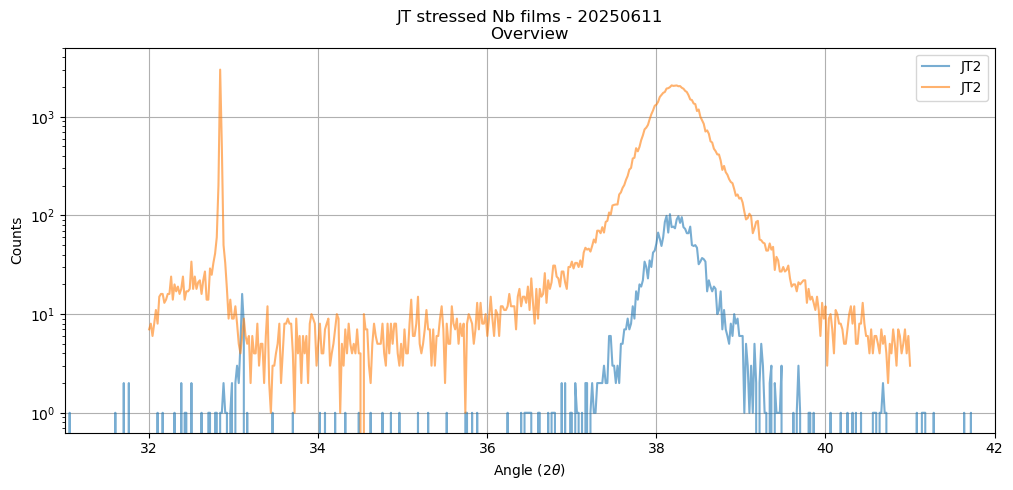

In [11]:
# Example usage
date = "20250611"

plt.figure(figsize=(12, 5))
plt.title(f"JT stressed Nb films - {date}\nOverview")
# plot_xy_data('JT1_Theta_2-Theta.xy')
plot_xy_data('JT2_Theta_2-Theta.xy')
# plot_xy_data('JT3_Theta_2-Theta.xy')
# plot_xy_data('JT4_Theta_2-Theta.xy')
# plot_xy_data('JT5_Theta_2-Theta.xy')
# plot_xy_data('JT6_Theta_2-Theta.xy')
# plot_xy_data('JT7_Theta_2-Theta.xy')
# plot_xy_data('JT8_Theta_2-Theta.xy')
# plot_xy_data('JT9_Theta_2-Theta.xy')
# plot_xy_data('JT10_Theta_2-Theta.xy')
# plot_xy_data('20250611_JT1_Theta_2-Theta.xy')
plot_xy_data('20250611_JT2_Theta_2-Theta.xy')
# plot_xy_data('20250611_JT3_Theta_2-Theta.xy')
# # plot_xy_data('20250611_JT4_Theta_2-Theta.xy') #??? idk why its not the correct data?
# plot_xy_data('20250611_JT5_Theta_2-Theta.xy')
# plot_xy_data('20250611_JT6_Theta_2-Theta.xy')
# plot_xy_data('20250611_JT7_Theta_2-Theta.xy')
# plot_xy_data('20250611_JT8_Theta_2-Theta.xy')
# plot_xy_data('20250611_JT9_Theta_2-Theta.xy')
# plot_xy_data('20250611_JT10_Theta_2-Theta.xy')
plt.xlabel(r'Angle (2$\theta$)')
# plt.text(33.2, 320, r"$\beta$-Ta 002",rotation = 90)
# plt.text(35.6, 30, r"$\beta$-Ta 410",rotation = 90)
# plt.text(37.9, 2400, r"$\alpha$-Ta 110",rotation = 90)
# plt.text(68.8, 95, r"Si 004",rotation = 90)
# plt.text(70.2, 90, r"$\beta$-Ta 004",rotation = 90)
# plt.text(81.6, 120, r"$\alpha$-Ta 220",rotation = 90)
plt.ylabel('Counts')
plt.yscale('log')
plt.ylim(0,5000)
plt.xlim(31,42)
plt.legend()
plt.grid(True)
plt.savefig(f'XRD_data_{date}.png',format='png')
plt.show()



JT1 peak (20250421) center (x0): 38.0358
JT1 peak (20250611) center (x0): 38.0359


/var/folders/gl/m1qd0tfj7zn_brj91bzzf3cr0000gn/T/ipykernel_42051/604692659.py:27: UserWarning: Attempted to set non-positive bottom ylim on a log-scaled axis.
Invalid limit will be ignored.
  plt.ylim(0,20000)


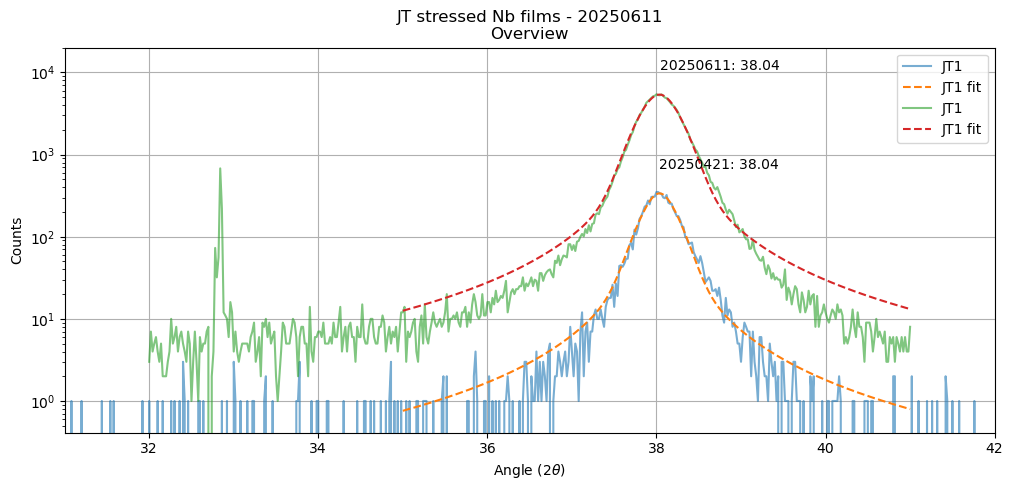

JT2 peak (20250421) center (x0): 38.2277
JT2 peak (20250611) center (x0): 38.2259


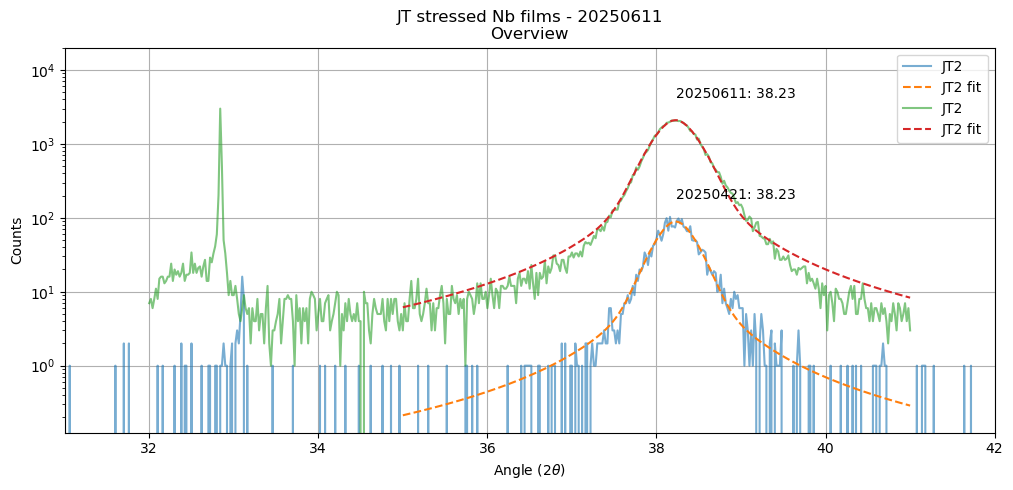

JT3 peak (20250421) center (x0): 38.1362
JT3 peak (20250611) center (x0): 38.1635


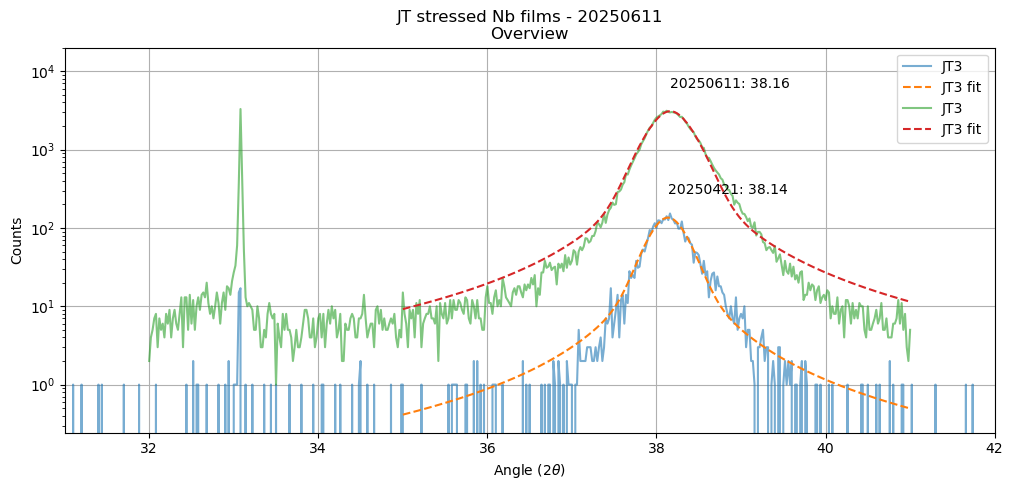

JT4 peak (20250421) center (x0): 38.4202


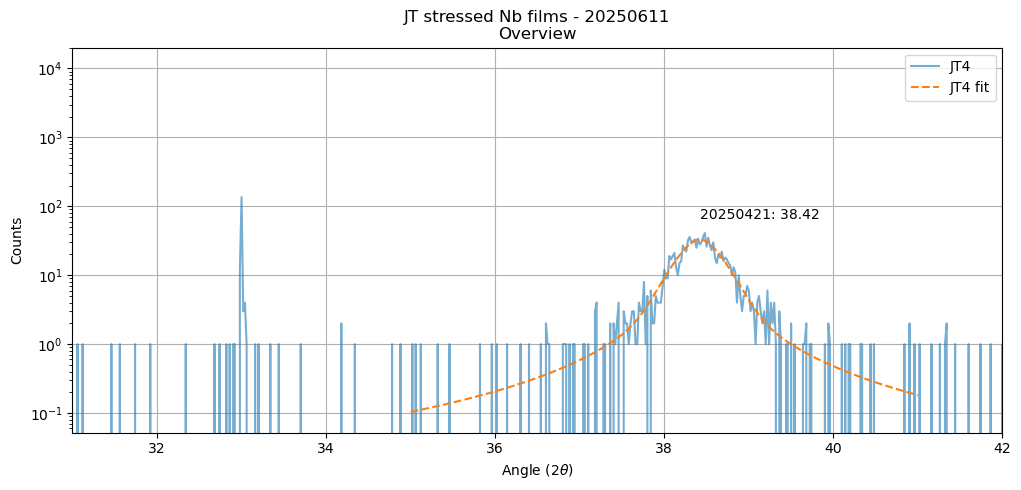

JT5 peak (20250421) center (x0): 38.2491
JT5 peak (20250611) center (x0): 38.2610


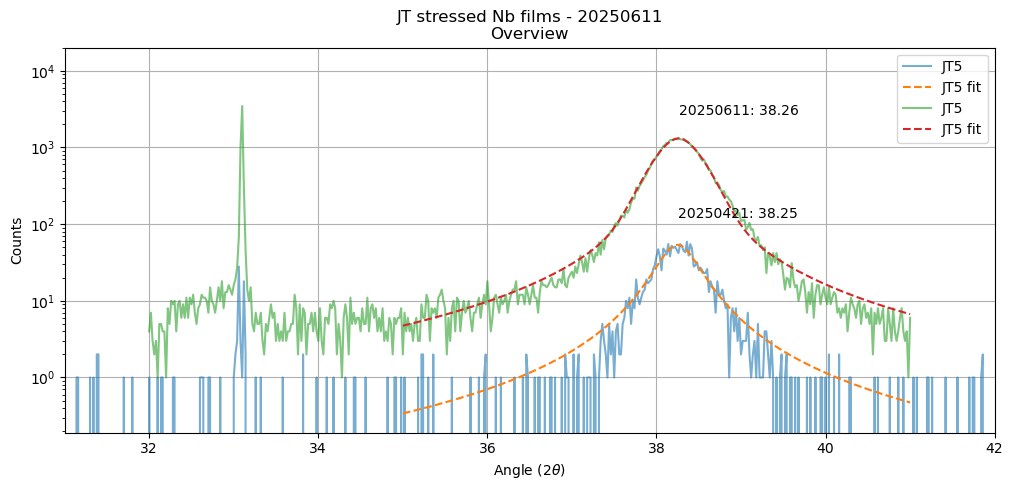

JT6 peak (20250421) center (x0): 38.2610
JT6 peak (20250611) center (x0): 38.2746


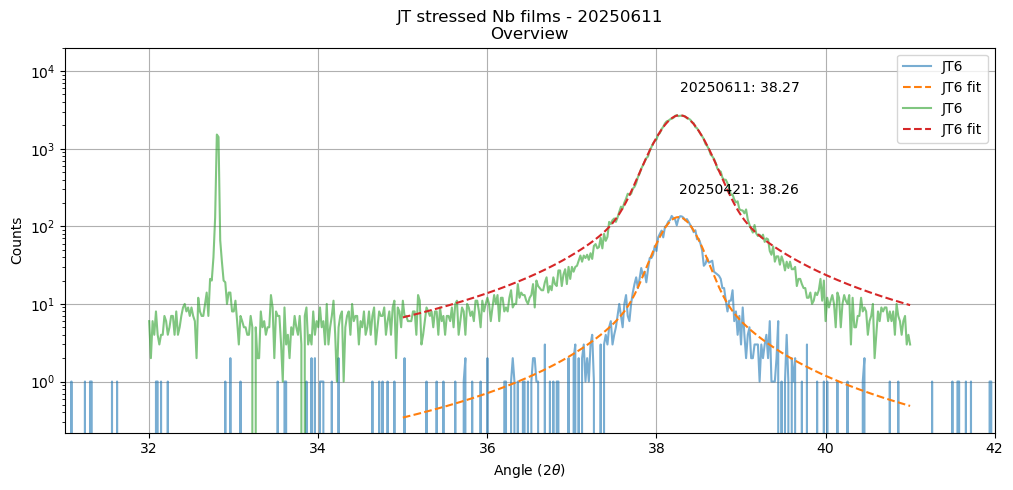

JT7 peak (20250421) center (x0): 38.2657
JT7 peak (20250611) center (x0): 38.2672


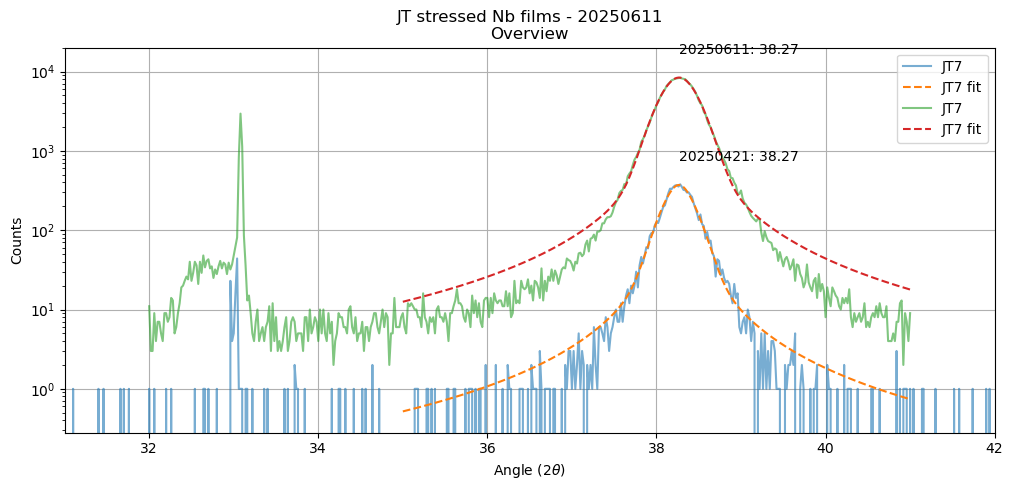

JT8 peak (20250421) center (x0): 38.1627
JT8 peak (20250611) center (x0): 38.1652


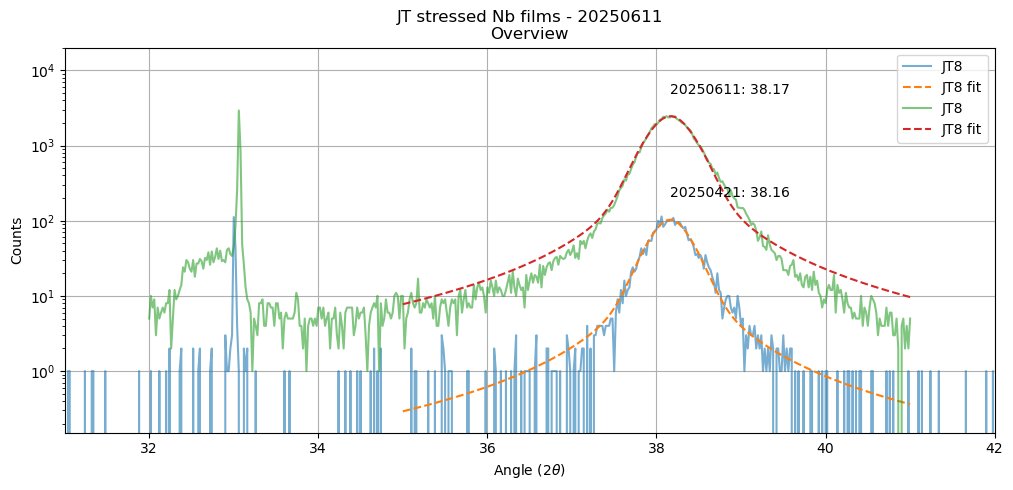

JT9 peak (20250421) center (x0): 38.1082
JT9 peak (20250611) center (x0): 38.1152


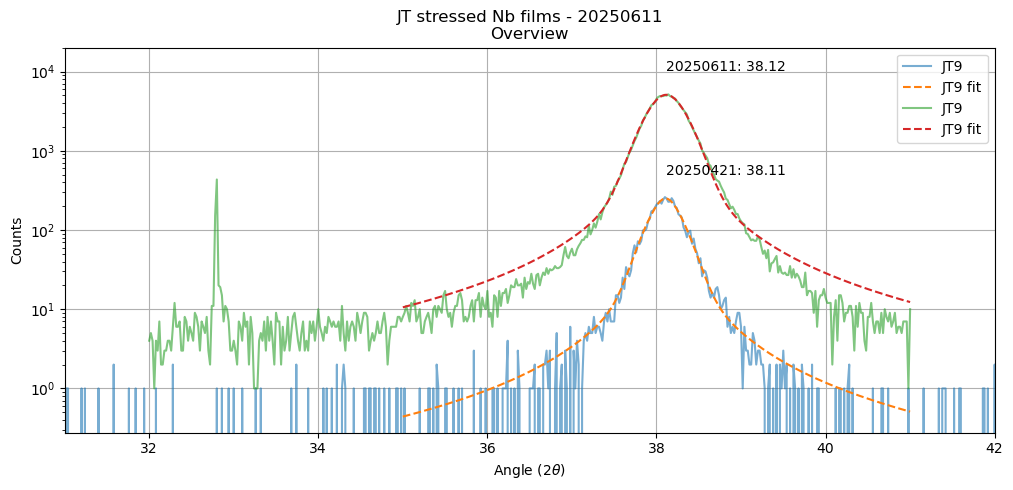

JT10 peak (20250421) center (x0): 38.2022
JT10 peak (20250611) center (x0): 38.2062


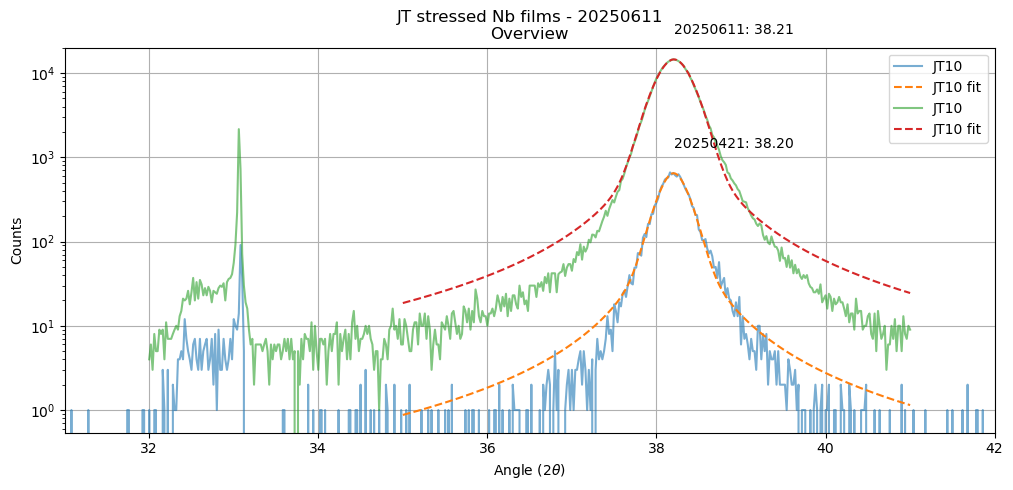

In [26]:
# Example usage
date = "20250611"

for i in range(10):
    plt.figure(figsize=(12, 5))
    plt.title(f"JT stressed Nb films - {date}\nOverview")

    plot_xy_data(f'JT{i+1}_Theta_2-Theta.xy')
    popt = plot_fit_data(f'JT{i+1}_Theta_2-Theta.xy')
    print(f"JT{i+1} peak (20250421) center (x0): {popt[1]:.4f}")
    plt.text(popt[1], popt[0]*2, f"20250421: {popt[1]:.2f}",rotation = 0)
    if i != 3:
        plot_xy_data(f'20250611_JT{i+1}_Theta_2-Theta.xy')
        popt = plot_fit_data(f'20250611_JT{i+1}_Theta_2-Theta.xy')
        print(f"JT{i+1} peak (20250611) center (x0): {popt[1]:.4f}")
        plt.text(popt[1], popt[0]*2, f"20250611: {popt[1]:.2f}",rotation = 0)

    plt.xlabel(r'Angle (2$\theta$)')
    # plt.text(33.2, 320, r"$\beta$-Ta 002",rotation = 90)
    # plt.text(35.6, 30, r"$\beta$-Ta 410",rotation = 90)
    # plt.text(37.9, 2400, r"$\alpha$-Ta 110",rotation = 90)
    # plt.text(68.8, 95, r"Si 004",rotation = 90)
    # plt.text(70.2, 90, r"$\beta$-Ta 004",rotation = 90)
    # plt.text(81.6, 120, r"$\alpha$-Ta 220",rotation = 90)
    plt.ylabel('Counts')
    plt.yscale('log')
    plt.ylim(0,20000)
    plt.xlim(31,42)
    plt.legend()
    plt.grid(True)
    plt.savefig(f'XRD_data_JT{i+1}.png',format='png')
    plt.show()



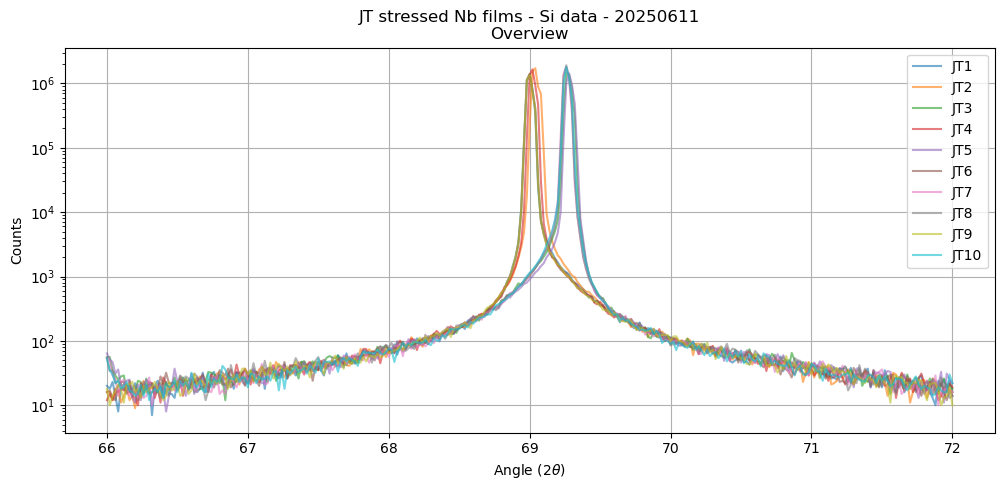

In [28]:
# Example usage
date = "20250611"

# for i in range(10):
plt.figure(figsize=(12, 5))
plt.title(f"JT stressed Nb films - Si data - {date}\nOverview")

for i in range(10):
    plot_xy_data(f'20250611_JT{i+1}Si_Theta_2-Theta.xy')
# popt = plot_fit_data(f'20250611_JT{i+1}Si_Theta_2-Theta.xy')
# print(f"JT{i+1} peak (20250611) center (x0): {popt[1]:.4f}")
# plt.text(popt[1], popt[0]*2, f"20250611: {popt[1]:.2f}",rotation = 0)

plt.xlabel(r'Angle (2$\theta$)')
# plt.text(33.2, 320, r"$\beta$-Ta 002",rotation = 90)
# plt.text(35.6, 30, r"$\beta$-Ta 410",rotation = 90)
# plt.text(37.9, 2400, r"$\alpha$-Ta 110",rotation = 90)
# plt.text(68.8, 95, r"Si 004",rotation = 90)
# plt.text(70.2, 90, r"$\beta$-Ta 004",rotation = 90)
# plt.text(81.6, 120, r"$\alpha$-Ta 220",rotation = 90)
plt.ylabel('Counts')
plt.yscale('log')
# plt.ylim(0,20000)
# plt.xlim(,42)
plt.legend()
plt.grid(True)
plt.savefig(f'XRD_data_JT{i+1}.png',format='png')
plt.show()



JT1 peak center (x0): 38.0358
JT2 peak center (x0): 38.2277
JT3 peak center (x0): 38.1362
JT4 peak center (x0): 38.4202


/var/folders/gl/m1qd0tfj7zn_brj91bzzf3cr0000gn/T/ipykernel_42051/2307270448.py:36: UserWarning: Attempted to set non-positive bottom ylim on a log-scaled axis.
Invalid limit will be ignored.
  plt.ylim(0,5000)


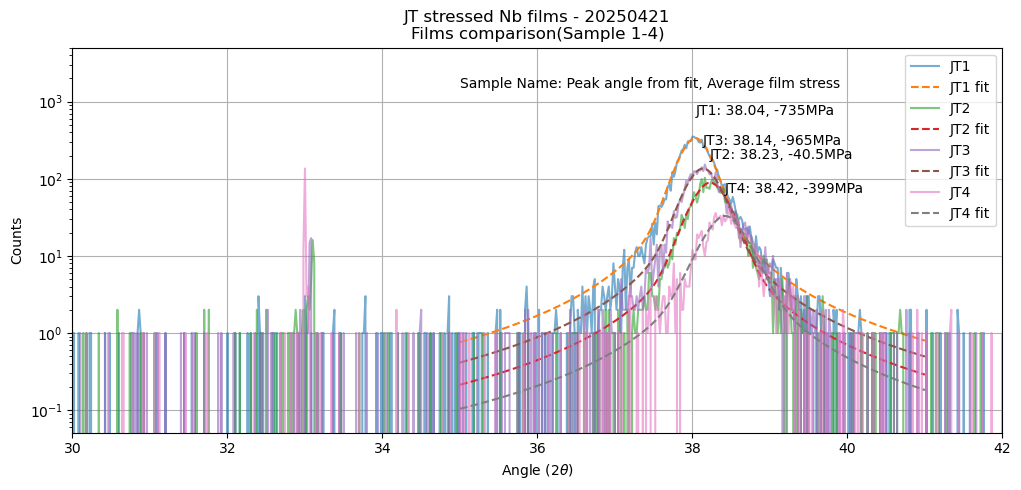

In [23]:
# Example usage
date = "20250421"

plt.figure(figsize=(12, 5))
plt.title(f"JT stressed Nb films - {date}\nFilms comparison(Sample 1-4)")
plt.text(35, 1500, "Sample Name: Peak angle from fit, Average film stress")

plot_xy_data('JT1_Theta_2-Theta.xy')
popt = plot_fit_data('JT1_Theta_2-Theta.xy')
print(f"JT1 peak center (x0): {popt[1]:.4f}")
plt.text(popt[1], popt[0]*2, f"JT1: {popt[1]:.2f}, -735MPa",rotation = 0)

plot_xy_data('JT2_Theta_2-Theta.xy')
popt = plot_fit_data('JT2_Theta_2-Theta.xy')
print(f"JT2 peak center (x0): {popt[1]:.4f}")
plt.text(popt[1], popt[0]*2, f"JT2: {popt[1]:.2f}, -40.5MPa",rotation = 0)

plot_xy_data('JT3_Theta_2-Theta.xy')
popt = plot_fit_data('JT3_Theta_2-Theta.xy')
print(f"JT3 peak center (x0): {popt[1]:.4f}")
plt.text(popt[1], popt[0]*2, f"JT3: {popt[1]:.2f}, -965MPa",rotation = 0)

plot_xy_data('JT4_Theta_2-Theta.xy')
popt = plot_fit_data('JT4_Theta_2-Theta.xy')
print(f"JT4 peak center (x0): {popt[1]:.4f}")
plt.text(popt[1], popt[0]*2, f"JT4: {popt[1]:.2f}, -399MPa",rotation = 0)
# plot_xy_data('JT5_Theta_2-Theta.xy')
# plot_xy_data('JT6_Theta_2-Theta.xy')
# plot_xy_data('JT7_Theta_2-Theta.xy')
# plot_xy_data('JT8_Theta_2-Theta.xy')
# plot_xy_data('JT9_Theta_2-Theta.xy')
# plot_xy_data('JT10_Theta_2-Theta.xy')
plt.xlabel(r'Angle (2$\theta$)')
plt.ylabel('Counts')
plt.yscale('log')
plt.ylim(0,5000)
plt.xlim(30,42)
plt.legend()
plt.grid(True)
plt.savefig(f'XRD_data_JT{i+1}.png',format='png')
plt.show()



/var/folders/gl/m1qd0tfj7zn_brj91bzzf3cr0000gn/T/ipykernel_56603/325247054.py:19: UserWarning: Attempted to set non-positive bottom ylim on a log-scaled axis.
Invalid limit will be ignored.
  plt.ylim(0,5000)


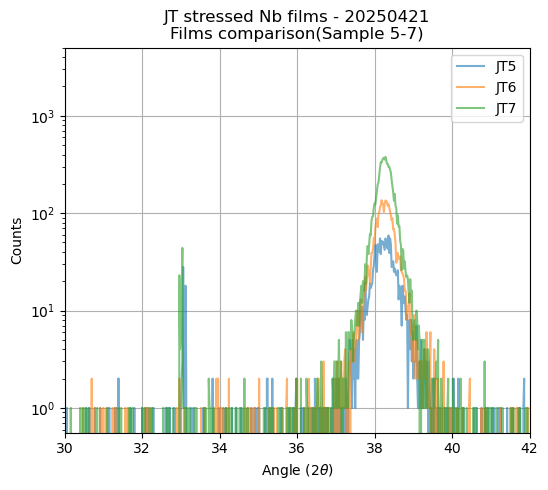

In [38]:
# Example usage
date = "20250421"

plt.figure(figsize=(6, 5))
plt.title(f"JT stressed Nb films - {date}\nFilms comparison(Sample 5-7)")
# plot_xy_data('JT1_Theta_2-Theta.xy')
# plot_xy_data('JT2_Theta_2-Theta.xy')
# plot_xy_data('JT3_Theta_2-Theta.xy')
# plot_xy_data('JT4_Theta_2-Theta.xy')
plot_xy_data('JT5_Theta_2-Theta.xy')
plot_xy_data('JT6_Theta_2-Theta.xy')
plot_xy_data('JT7_Theta_2-Theta.xy')
# plot_xy_data('JT8_Theta_2-Theta.xy')
# plot_xy_data('JT9_Theta_2-Theta.xy')
# plot_xy_data('JT10_Theta_2-Theta.xy')
plt.xlabel(r'Angle (2$\theta$)')
plt.ylabel('Counts')
plt.yscale('log')
plt.ylim(0,5000)
plt.xlim(30,42)
plt.legend()
plt.grid(True)
plt.savefig(f'XRD_data_{date}.png',format='png')
plt.show()



/var/folders/gl/m1qd0tfj7zn_brj91bzzf3cr0000gn/T/ipykernel_56603/2561363542.py:19: UserWarning: Attempted to set non-positive bottom ylim on a log-scaled axis.
Invalid limit will be ignored.
  plt.ylim(0,5000)


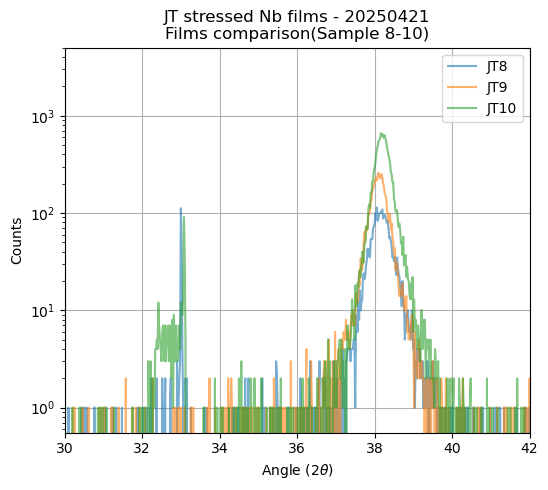

In [37]:
# Example usage
date = "20250421"

plt.figure(figsize=(6, 5))
plt.title(f"JT stressed Nb films - {date}\nFilms comparison(Sample 8-10)")
# plot_xy_data('JT1_Theta_2-Theta.xy')
# plot_xy_data('JT2_Theta_2-Theta.xy')
# plot_xy_data('JT3_Theta_2-Theta.xy')
# plot_xy_data('JT4_Theta_2-Theta.xy')
# plot_xy_data('JT5_Theta_2-Theta.xy')
# plot_xy_data('JT6_Theta_2-Theta.xy')
# plot_xy_data('JT7_Theta_2-Theta.xy')
plot_xy_data('JT8_Theta_2-Theta.xy')
plot_xy_data('JT9_Theta_2-Theta.xy')
plot_xy_data('JT10_Theta_2-Theta.xy')
plt.xlabel(r'Angle (2$\theta$)')
plt.ylabel('Counts')
plt.yscale('log')
plt.ylim(0,5000)
plt.xlim(30,42)
plt.legend()
plt.grid(True)
plt.savefig(f'XRD_data_{date}.png',format='png')
plt.show()



JT5 peak center (x0): 38.2491
JT8 peak center (x0): 38.1627


/var/folders/gl/m1qd0tfj7zn_brj91bzzf3cr0000gn/T/ipykernel_56603/791567001.py:28: UserWarning: Attempted to set non-positive bottom ylim on a log-scaled axis.
Invalid limit will be ignored.
  plt.ylim(0,5000)


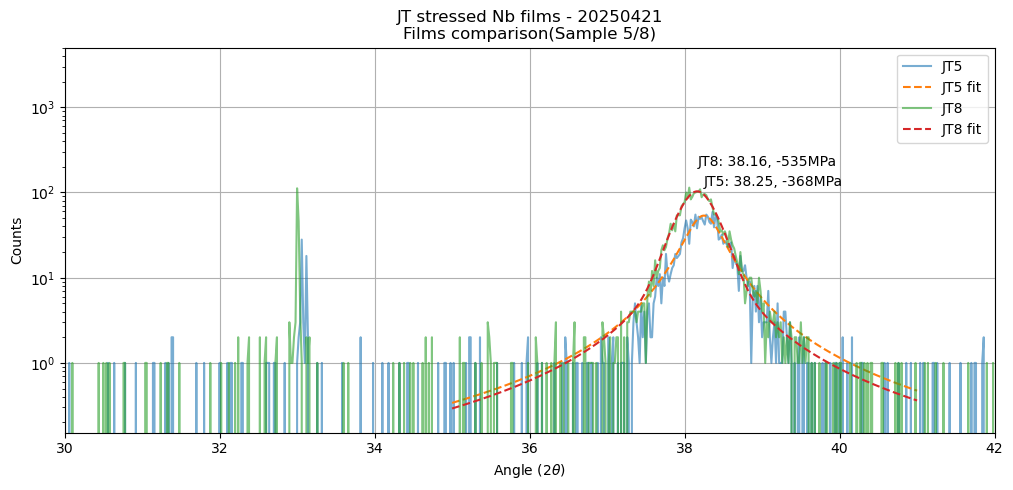

In [39]:
# Example usage
date = "20250421"

plt.figure(figsize=(12, 5))
plt.title(f"JT stressed Nb films - {date}\nFilms comparison(Sample 5/8)")
# plot_xy_data('JT1_Theta_2-Theta.xy')
# plot_xy_data('JT2_Theta_2-Theta.xy')
# plot_xy_data('JT3_Theta_2-Theta.xy')
# plot_xy_data('JT4_Theta_2-Theta.xy')
plot_xy_data('JT5_Theta_2-Theta.xy')
popt = plot_fit_data('JT5_Theta_2-Theta.xy')
print(f"JT5 peak center (x0): {popt[1]:.4f}")
plt.text(popt[1], popt[0]*2, f"JT5: {popt[1]:.2f}, -368MPa",rotation = 0)

# plot_xy_data('JT6_Theta_2-Theta.xy')
# plot_xy_data('JT7_Theta_2-Theta.xy')
plot_xy_data('JT8_Theta_2-Theta.xy')
popt = plot_fit_data('JT8_Theta_2-Theta.xy')
print(f"JT8 peak center (x0): {popt[1]:.4f}")
plt.text(popt[1], popt[0]*2, f"JT8: {popt[1]:.2f}, -535MPa",rotation = 0)


# plot_xy_data('JT9_Theta_2-Theta.xy')
# plot_xy_data('JT10_Theta_2-Theta.xy')
plt.xlabel(r'Angle (2$\theta$)')
plt.ylabel('Counts')
plt.yscale('log')
plt.ylim(0,5000)
plt.xlim(30,42)
plt.legend()
plt.grid(True)
plt.savefig(f'XRD_data_{date}.png',format='png')
plt.show()



JT6 peak center (x0): 38.2610
JT9 peak center (x0): 38.1082


/var/folders/gl/m1qd0tfj7zn_brj91bzzf3cr0000gn/T/ipykernel_56603/555474249.py:25: UserWarning: Attempted to set non-positive bottom ylim on a log-scaled axis.
Invalid limit will be ignored.
  plt.ylim(0,5000)


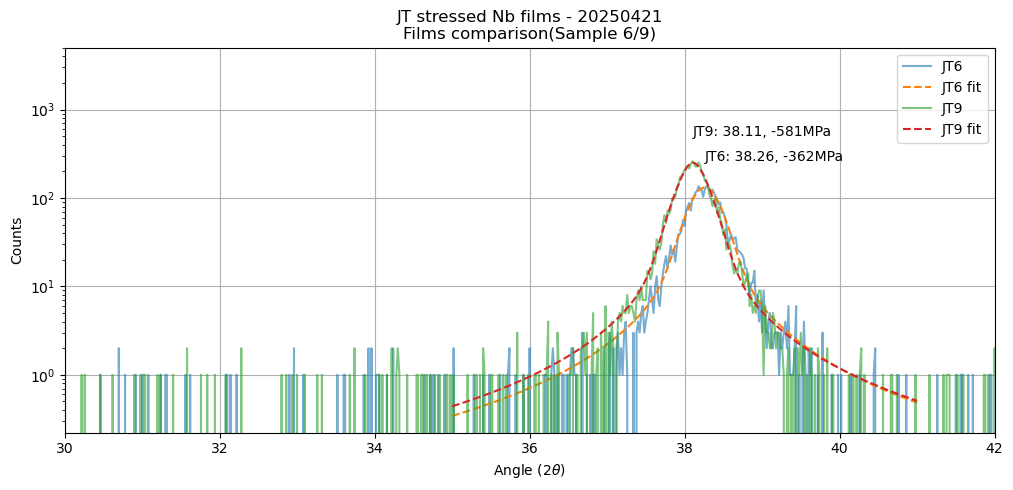

In [40]:
# Example usage
date = "20250421"

plt.figure(figsize=(12, 5))
plt.title(f"JT stressed Nb films - {date}\nFilms comparison(Sample 6/9)")
# plot_xy_data('JT1_Theta_2-Theta.xy')
# plot_xy_data('JT2_Theta_2-Theta.xy')
# plot_xy_data('JT3_Theta_2-Theta.xy')
# plot_xy_data('JT4_Theta_2-Theta.xy')
# plot_xy_data('JT5_Theta_2-Theta.xy')
plot_xy_data('JT6_Theta_2-Theta.xy')
popt = plot_fit_data('JT6_Theta_2-Theta.xy')
print(f"JT6 peak center (x0): {popt[1]:.4f}")
plt.text(popt[1], popt[0]*2, f"JT6: {popt[1]:.2f}, -362MPa",rotation = 0)
# plot_xy_data('JT7_Theta_2-Theta.xy')
# plot_xy_data('JT8_Theta_2-Theta.xy')
plot_xy_data('JT9_Theta_2-Theta.xy')
popt = plot_fit_data('JT9_Theta_2-Theta.xy')
print(f"JT9 peak center (x0): {popt[1]:.4f}")
plt.text(popt[1], popt[0]*2, f"JT9: {popt[1]:.2f}, -581MPa",rotation = 0)
# plot_xy_data('JT10_Theta_2-Theta.xy')
plt.xlabel(r'Angle (2$\theta$)')
plt.ylabel('Counts')
plt.yscale('log')
plt.ylim(0,5000)
plt.xlim(30,42)
plt.legend()
plt.grid(True)
plt.savefig(f'XRD_data_{date}.png',format='png')
plt.show()



JT7 peak center (x0): 38.2657
JT10 peak center (x0): 38.2022


/var/folders/gl/m1qd0tfj7zn_brj91bzzf3cr0000gn/T/ipykernel_56603/2055381952.py:26: UserWarning: Attempted to set non-positive bottom ylim on a log-scaled axis.
Invalid limit will be ignored.
  plt.ylim(0,5000)


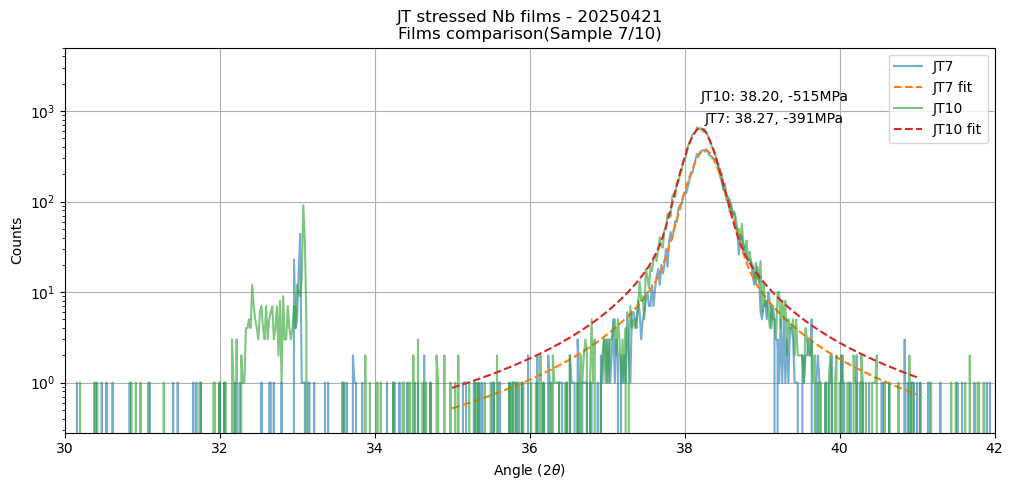

In [41]:
# Example usage
date = "20250421"

plt.figure(figsize=(12, 5))
plt.title(f"JT stressed Nb films - {date}\nFilms comparison(Sample 7/10)")
# plot_xy_data('JT1_Theta_2-Theta.xy')
# plot_xy_data('JT2_Theta_2-Theta.xy')
# plot_xy_data('JT3_Theta_2-Theta.xy')
# plot_xy_data('JT4_Theta_2-Theta.xy')
# plot_xy_data('JT5_Theta_2-Theta.xy')
# plot_xy_data('JT6_Theta_2-Theta.xy')
plot_xy_data('JT7_Theta_2-Theta.xy')
popt = plot_fit_data('JT7_Theta_2-Theta.xy')
print(f"JT7 peak center (x0): {popt[1]:.4f}")
plt.text(popt[1], popt[0]*2, f"JT7: {popt[1]:.2f}, -391MPa",rotation = 0)

# plot_xy_data('JT8_Theta_2-Theta.xy')
# plot_xy_data('JT9_Theta_2-Theta.xy')
plot_xy_data('JT10_Theta_2-Theta.xy')
popt = plot_fit_data('JT10_Theta_2-Theta.xy')
print(f"JT10 peak center (x0): {popt[1]:.4f}")
plt.text(popt[1], popt[0]*2, f"JT10: {popt[1]:.2f}, -515MPa",rotation = 0)
plt.xlabel(r'Angle (2$\theta$)')
plt.ylabel('Counts')
plt.yscale('log')
plt.ylim(0,5000)
plt.xlim(30,42)
plt.legend()
plt.grid(True)
plt.savefig(f'XRD_data_{date}.png',format='png')
plt.show()



/var/folders/gl/m1qd0tfj7zn_brj91bzzf3cr0000gn/T/ipykernel_56603/765714064.py:21: UserWarning: Attempted to set non-positive bottom ylim on a log-scaled axis.
Invalid limit will be ignored.
  plt.ylim(0,5000)


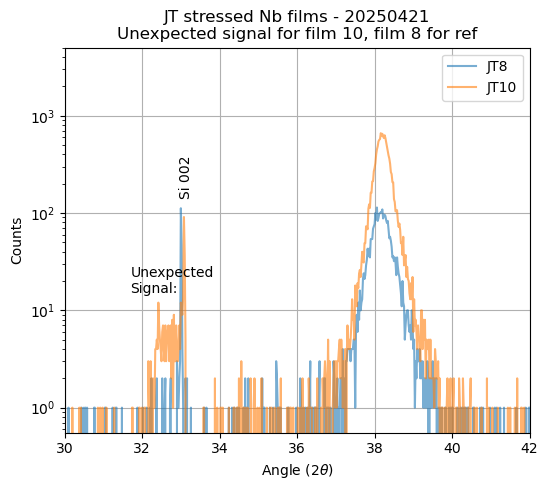

In [42]:
# Example usage
date = "20250421"

plt.figure(figsize=(6, 5))
plt.title(f"JT stressed Nb films - {date}\nUnexpected signal for film 10, film 8 for ref")
# plot_xy_data('JT1_Theta_2-Theta.xy')
# plot_xy_data('JT2_Theta_2-Theta.xy')
# plot_xy_data('JT3_Theta_2-Theta.xy')
# plot_xy_data('JT4_Theta_2-Theta.xy')
# plot_xy_data('JT5_Theta_2-Theta.xy')
# plot_xy_data('JT6_Theta_2-Theta.xy')
# plot_xy_data('JT7_Theta_2-Theta.xy')
plot_xy_data('JT8_Theta_2-Theta.xy')
# plot_xy_data('JT9_Theta_2-Theta.xy')
plot_xy_data('JT10_Theta_2-Theta.xy')
plt.xlabel(r'Angle (2$\theta$)')
plt.text(32.95, 150, r"Si 002",rotation = 90)
plt.text(31.7, 15, "Unexpected\nSignal:")
plt.ylabel('Counts')
plt.yscale('log')
plt.ylim(0,5000)
plt.xlim(30,42)
plt.legend()
plt.grid(True)
plt.savefig(f'XRD_data_{date}.png',format='png')
plt.show()

